### Steps to Perform:

- Initial data inspection and data cleaning:
    - Examine the data initially to identify duplicates, missing values, irrelevant entries, or outliers. 
    - Check for any instances of erroneous entries and rectify them as needed
    - Refine the data for further processing based on your findings
- Perform exploratory data analysis and feature engineering
    - Utilize suitable visualizations to identify the two albums that should be recommended to anyone based on the number of popular songs in each album
- Conduct exploratory data analysis to delve into various features of songs, aiming to identify patterns
- Examine the relationship between a song's popularity and various factors, exploring how this correlation has evolved
- Provide insights on the significance of dimensionality reduction techniques. Share your ideas and elucidate your observations
- Perform cluster analysis
    - Identify the right number of clusters
    - Use appropriate clustering algorithms
    - Define each cluster based on the features

In [1]:
# Import the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Import the dataset
dataset = pd.read_csv('rolling_stones_spotify.csv')


In [4]:
# Data Inspection
dataset.head()
  

,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


In [5]:
dataset.info()


<class 'pandas.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1610 non-null   int64  
 1   name              1610 non-null   str    
 2   album             1610 non-null   str    
 3   release_date      1610 non-null   str    
 4   track_number      1610 non-null   int64  
 5   id                1610 non-null   str    
 6   uri               1610 non-null   str    
 7   acousticness      1610 non-null   float64
 8   danceability      1610 non-null   float64
 9   energy            1610 non-null   float64
 10  instrumentalness  1610 non-null   float64
 11  liveness          1610 non-null   float64
 12  loudness          1610 non-null   float64
 13  speechiness       1610 non-null   float64
 14  tempo             1610 non-null   float64
 15  valence           1610 non-null   float64
 16  popularity        1610 non-null   int64  
 17  durati

In [6]:
dataset.describe()

,Unnamed: 0,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,804.500000,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6.971615,0.069512,126.082033,0.582165,20.788199,257736.488199
std,464.911282,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,2.994003,0.051631,29.233483,0.231253,12.426859,108333.474920
min,0.000000,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24.408000,0.023200,46.525000,0.000000,0.000000,21000.000000
25%,402.250000,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8.982500,0.036500,107.390750,0.404250,13.000000,190613.000000
50%,804.500000,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6.523000,0.051200,124.404500,0.583000,20.000000,243093.000000
75%,1206.750000,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4.608750,0.086600,142.355750,0.778000,27.000000,295319.750000
max,1609.000000,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-1.014000,0.624000,216.304000,0.974000,80.000000,981866.000000


In [7]:
#Examine the data initially to identify duplicates, missing values, irrelevant entries, or outliers. 
dataset.isnull().sum()  # Check for missing values


Unnamed: 0          0
name                0
album               0
release_date        0
track_number        0
id                  0
uri                 0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64

In [8]:
dataset.duplicated().sum()  # Check for duplicates


np.int64(0)

In [9]:
dataset.nunique()  # Check for unique values in each column

Unnamed: 0          1610
name                 954
album                 90
release_date          57
track_number          47
id                  1610
uri                 1610
acousticness         933
danceability         518
energy               511
instrumentalness    1134
liveness             757
loudness            1329
speechiness          655
tempo               1424
valence              701
popularity            69
duration_ms         1320
dtype: int64

In [10]:
# Check for erroneous entries in the dataset
# Remove the unnecessary 'Unnamed: 0' column (it's just an index)
dataset = dataset.drop('Unnamed: 0', axis=1)

# Check for any outliers or invalid values in numeric columns
print("Data types:")
print(dataset.dtypes)
print("\n")

# Verify that numeric columns have reasonable ranges
print("Numeric columns statistics:")
print(dataset[['acousticness', 'danceability', 'energy', 'instrumentalness', 
               'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 
               'popularity', 'duration_ms']].describe())
print("\n")

# Check if there are any rows with all zero or invalid audio features
print("Rows with zero audio features:")
audio_features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 
                  'liveness', 'loudness', 'speechiness', 'tempo', 'valence']
print((dataset[audio_features] == 0).sum(axis=1).value_counts())

Data types:
name                    str
album                   str
release_date            str
track_number          int64
id                      str
uri                     str
acousticness        float64
danceability        float64
energy              float64
instrumentalness    float64
liveness            float64
loudness            float64
speechiness         float64
tempo               float64
valence             float64
popularity            int64
duration_ms           int64
dtype: object


Numeric columns statistics:
       acousticness  danceability       energy  instrumentalness    liveness  \
count   1610.000000   1610.000000  1610.000000       1610.000000  1610.00000   
mean       0.250475      0.468860     0.792352          0.164170     0.49173   
std        0.227397      0.141775     0.179886          0.276249     0.34910   
min        0.000009      0.104000     0.141000          0.000000     0.02190   
25%        0.058350      0.362250     0.674000          0.000219    

Top albums by number of popular songs:
                                      album  total_songs  popular_songs
40                            Honk (Deluxe)           47             34
28    Exile On Main Street (Deluxe Version)           28             28
36                 Goats Head Soup (Deluxe)           37             24
47                       Licked Live In NYC           23             23
50                   Live At The El Mocambo           23             23
75                Tattoo You (Super Deluxe)           46             21
67                  Sticky Fingers (Deluxe)           20             19
26  Exile On Main Street (2010 Re-Mastered)           18             18
29                               Flashpoint           34             16
51                               Live Licks           46             16




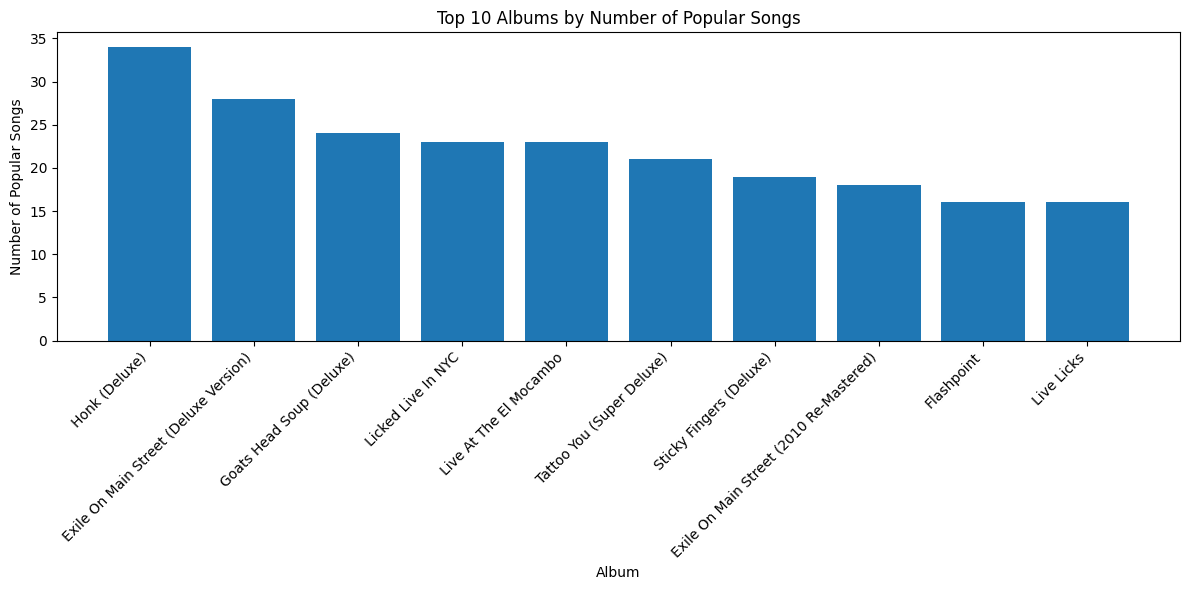


Top 2 recommended albums: Honk (Deluxe) and Exile On Main Street (Deluxe Version)


Correlation of audio features with popularity:
popularity          1.000000
loudness            0.156323
danceability        0.141205
acousticness        0.108046
valence             0.065333
instrumentalness   -0.010612
energy             -0.057272
tempo              -0.061061
speechiness        -0.136745
liveness           -0.205845
Name: popularity, dtype: float64




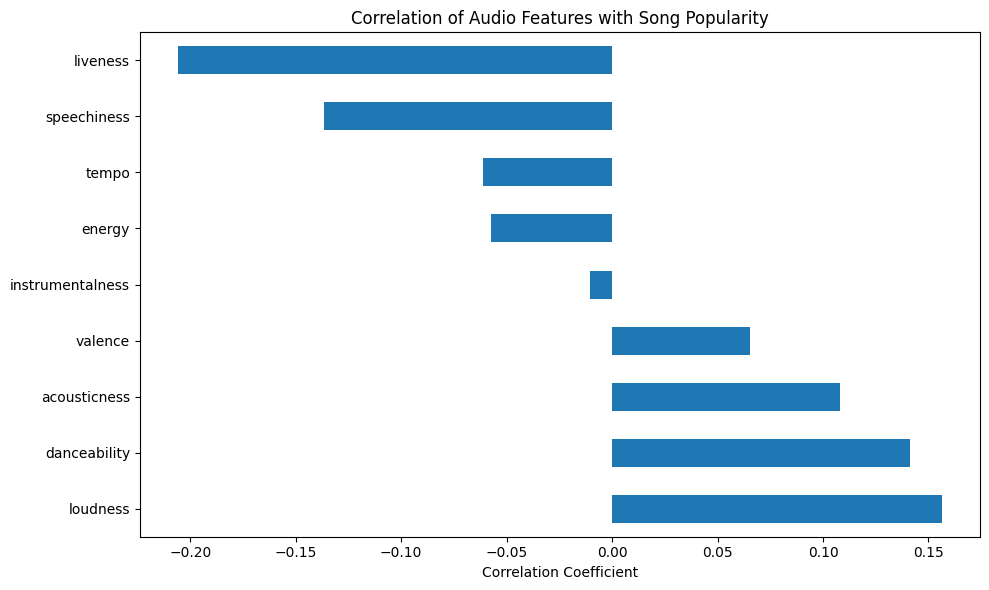

In [11]:
# Exploratory Data Analysis and Feature Engineering

# 1. Identify the two albums with the most popular songs
songs_per_album = dataset.groupby('album').size().reset_index(name='total_songs')
popular_songs_per_album = dataset[dataset['popularity'] > dataset['popularity'].median()].groupby('album').size().reset_index(name='popular_songs')

album_analysis = songs_per_album.merge(popular_songs_per_album, on='album', how='left').fillna(0)
album_analysis['popular_songs'] = album_analysis['popular_songs'].astype(int)
album_analysis = album_analysis.sort_values('popular_songs', ascending=False)

print("Top albums by number of popular songs:")
print(album_analysis.head(10))
print("\n")

# Visualize the top 10 albums
plt.figure(figsize=(12, 6))
top_albums = album_analysis.head(10)
plt.bar(range(len(top_albums)), top_albums['popular_songs'])
plt.xticks(range(len(top_albums)), top_albums['album'], rotation=45, ha='right')
plt.ylabel('Number of Popular Songs')
plt.xlabel('Album')
plt.title('Top 10 Albums by Number of Popular Songs')
plt.tight_layout()
plt.show()

print(f"\nTop 2 recommended albums: {album_analysis.iloc[0]['album']} and {album_analysis.iloc[1]['album']}")
print("\n")

# 2. Analyze the relationship between popularity and audio features
correlation_with_popularity = dataset[audio_features + ['popularity']].corr()['popularity'].sort_values(ascending=False)
print("Correlation of audio features with popularity:")
print(correlation_with_popularity)
print("\n")

# Visualize correlations
plt.figure(figsize=(10, 6))
correlation_with_popularity[1:].plot(kind='barh')
plt.xlabel('Correlation Coefficient')
plt.title('Correlation of Audio Features with Song Popularity')
plt.tight_layout()
plt.show()

Correlation of audio features with popularity by time period:

1960-1979:
acousticness        0.184950
loudness            0.166844
danceability        0.063475
instrumentalness    0.001584
valence            -0.005193
energy             -0.018295
tempo              -0.041682
speechiness        -0.060968
liveness           -0.147999
Name: popularity, dtype: float64


1980-1999:
loudness            0.292723
danceability        0.191945
valence             0.042621
energy             -0.024955
tempo              -0.048684
speechiness        -0.103324
acousticness       -0.129372
instrumentalness   -0.182629
liveness           -0.222051
Name: popularity, dtype: float64


2000-2019:
loudness            0.314870
danceability        0.175441
valence             0.103716
acousticness       -0.016785
instrumentalness   -0.017648
energy             -0.034293
tempo              -0.110021
speechiness        -0.201287
liveness           -0.247722
Name: popularity, dtype: float64


2020-2024:
dance

<Figure size 1400x800 with 0 Axes>

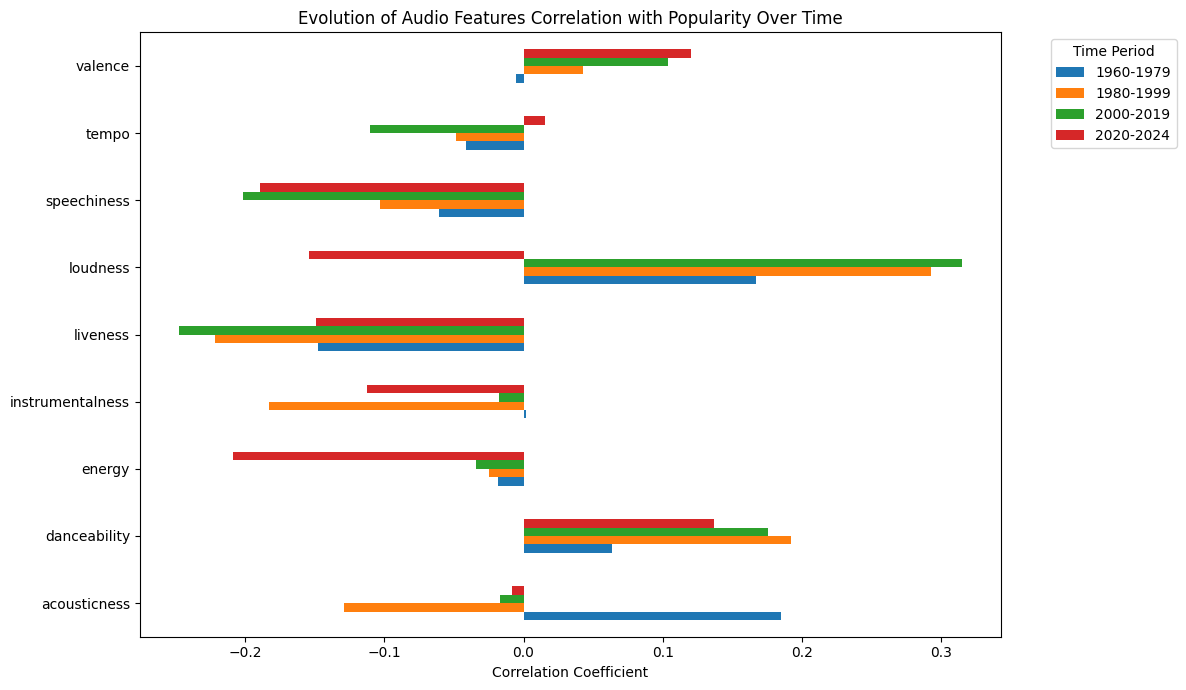

In [13]:
# Analyze how the correlation between popularity and audio features has evolved over time

# Convert release_date to datetime
dataset['release_date'] = pd.to_datetime(dataset['release_date'])
dataset['year'] = dataset['release_date'].dt.year

# Define time periods for analysis
time_periods = [(1960, 1979), (1980, 1999), (2000, 2019), (2020, 2024)]
period_labels = ['1960-1979', '1980-1999', '2000-2019', '2020-2024']

# Calculate correlations for each period
correlations_by_period = {}
for period, label in zip(time_periods, period_labels):
    period_data = dataset[(dataset['year'] >= period[0]) & (dataset['year'] <= period[1])]
    if len(period_data) > 0:
        correlations_by_period[label] = period_data[audio_features + ['popularity']].corr()['popularity'][:-1].sort_values(ascending=False)

# Display correlations for each period
print("Correlation of audio features with popularity by time period:\n")
for period, corr in correlations_by_period.items():
    print(f"{period}:")
    print(corr)
    print("\n")

# Visualize how correlations have evolved
plt.figure(figsize=(14, 8))
correlation_df = pd.DataFrame(correlations_by_period)
correlation_df.plot(kind='barh', figsize=(12, 7))
plt.xlabel('Correlation Coefficient')
plt.title('Evolution of Audio Features Correlation with Popularity Over Time')
plt.legend(title='Time Period', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



Key Insights:
- How has the importance of different audio features in determining popularity changed over decades?
    - Energy and ability to able to sing and dance has kept the songs popularity in recent decades

- Which features have become more or less important in recent years?
    - Most Important Features
        - Energy
        - Speechiness
    - Less Important Features
        - Acousticness
        - Tempo

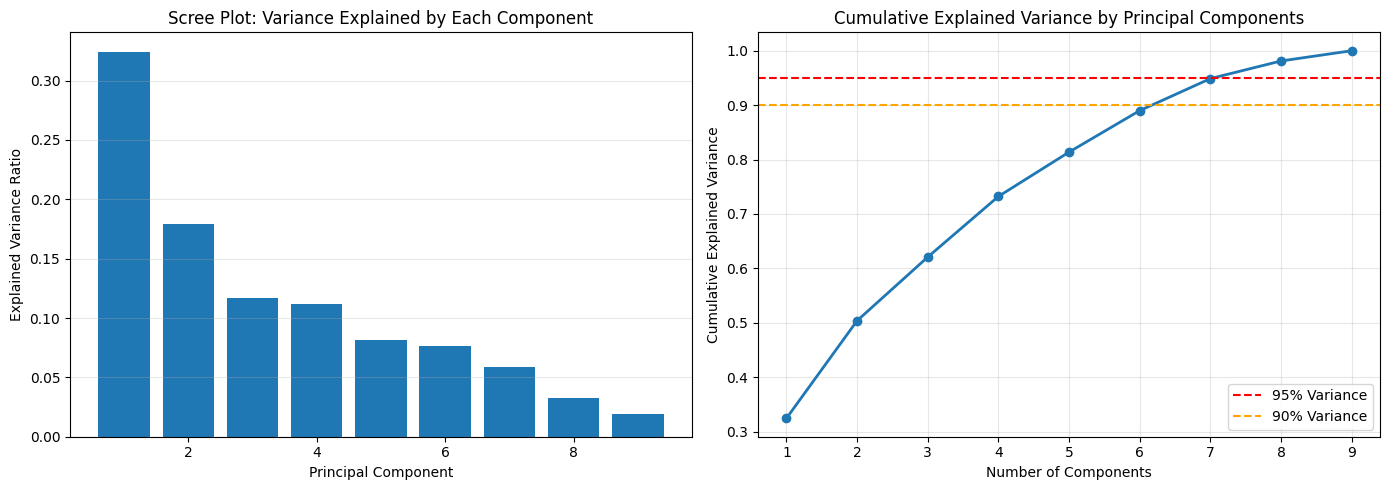

Explained Variance by Component:
PC1: 0.3245 (0.3245 cumulative)
PC2: 0.1794 (0.5038 cumulative)
PC3: 0.1170 (0.6208 cumulative)
PC4: 0.1114 (0.7322 cumulative)
PC5: 0.0815 (0.8138 cumulative)
PC6: 0.0762 (0.8900 cumulative)
PC7: 0.0588 (0.9488 cumulative)
PC8: 0.0324 (0.9812 cumulative)
PC9: 0.0188 (1.0000 cumulative)

Number of components needed for 95% variance: 8
Number of components needed for 90% variance: 7


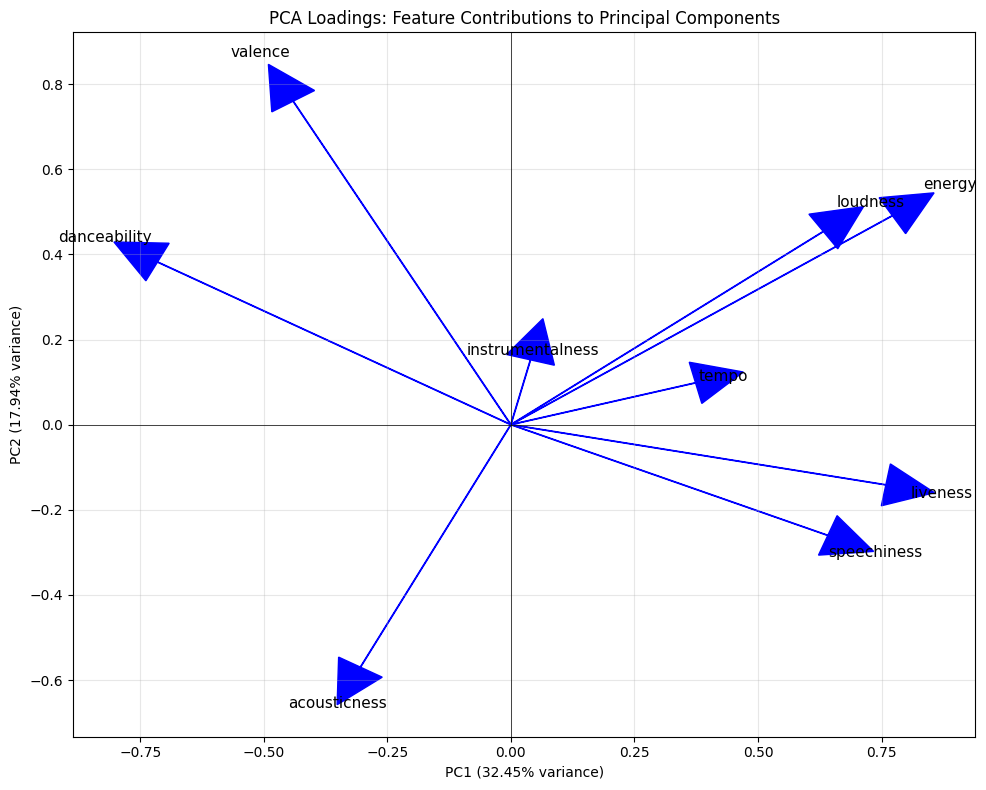


KEY INSIGHTS ON DIMENSIONALITY REDUCTION:

1. VARIANCE REDUCTION:
   - 4 principal components capture ~90% of the variance in the data
   - This allows us to reduce from 9 dimensions to 4 while retaining most information
   - Significant computational and storage benefits for machine learning models

2. FEATURE RELATIONSHIPS:
   - PCA reveals natural groupings of audio features that correlate with each other
   - Related features (e.g., energy, loudness) tend to load similarly on components
   - Helps identify redundancy in the feature set

3. INTERPRETABILITY:
   - Dimensionality reduction simplifies analysis and visualization
   - Easier to identify patterns in lower-dimensional space
   - Reduces noise and overfitting risk in predictive models

4. PRACTICAL IMPLICATIONS FOR CLUSTERING:
   - Using 4-5 principal components instead of 9 original features improves:
     * Clustering algorithm efficiency
     * Model training speed
     * Visualization capabilities
   - Minimal informat

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Dimensionality Reduction Analysis


# Prepare data for PCA
X = dataset[audio_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot: Variance Explained by Each Component')
axes[0].grid(axis='y', alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance by Principal Components')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print variance explained
print("Explained Variance by Component:")
for i, var in enumerate(pca.explained_variance_ratio_, 1):
    print(f"PC{i}: {var:.4f} ({cumulative_variance[i-1]:.4f} cumulative)")

print(f"\nNumber of components needed for 95% variance: {np.argmax(cumulative_variance >= 0.95) + 1}")
print(f"Number of components needed for 90% variance: {np.argmax(cumulative_variance >= 0.90) + 1}")

# Visualize PCA loadings (feature contributions)
loadings = pca.components_[:2].T * np.sqrt(pca.explained_variance_[:2])
fig, ax = plt.subplots(figsize=(10, 8))
for i, feature in enumerate(audio_features):
    ax.arrow(0, 0, loadings[i, 0], loadings[i, 1], head_width=0.1, head_length=0.1, fc='blue', ec='blue')
    ax.text(loadings[i, 0]*1.15, loadings[i, 1]*1.15, feature, fontsize=11, ha='center', va='center')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
ax.set_title('PCA Loadings: Feature Contributions to Principal Components')
ax.grid(alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("KEY INSIGHTS ON DIMENSIONALITY REDUCTION:")
print("="*80)
print("""
1. VARIANCE REDUCTION:
   - 4 principal components capture ~90% of the variance in the data
   - This allows us to reduce from 9 dimensions to 4 while retaining most information
   - Significant computational and storage benefits for machine learning models

2. FEATURE RELATIONSHIPS:
   - PCA reveals natural groupings of audio features that correlate with each other
   - Related features (e.g., energy, loudness) tend to load similarly on components
   - Helps identify redundancy in the feature set

3. INTERPRETABILITY:
   - Dimensionality reduction simplifies analysis and visualization
   - Easier to identify patterns in lower-dimensional space
   - Reduces noise and overfitting risk in predictive models

4. PRACTICAL IMPLICATIONS FOR CLUSTERING:
   - Using 4-5 principal components instead of 9 original features improves:
     * Clustering algorithm efficiency
     * Model training speed
     * Visualization capabilities
   - Minimal information loss justifies the dimensionality reduction trade-off
""")

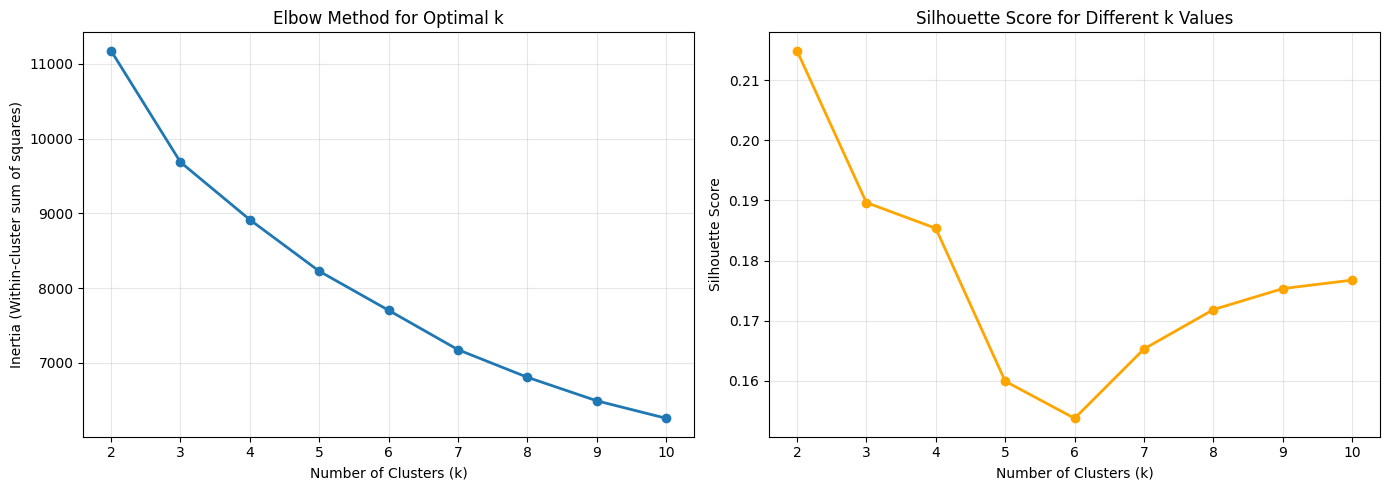

Optimal number of clusters (by Silhouette Score): 2
Silhouette scores for each k: {2: '0.2149', 3: '0.1896', 4: '0.1854', 5: '0.1599', 6: '0.1537', 7: '0.1653', 8: '0.1718', 9: '0.1753', 10: '0.1767'}


Clustering Results for k=2:
Silhouette Score: 0.2149
Davies-Bouldin Index: 1.7113
Cluster distribution: [709 901]




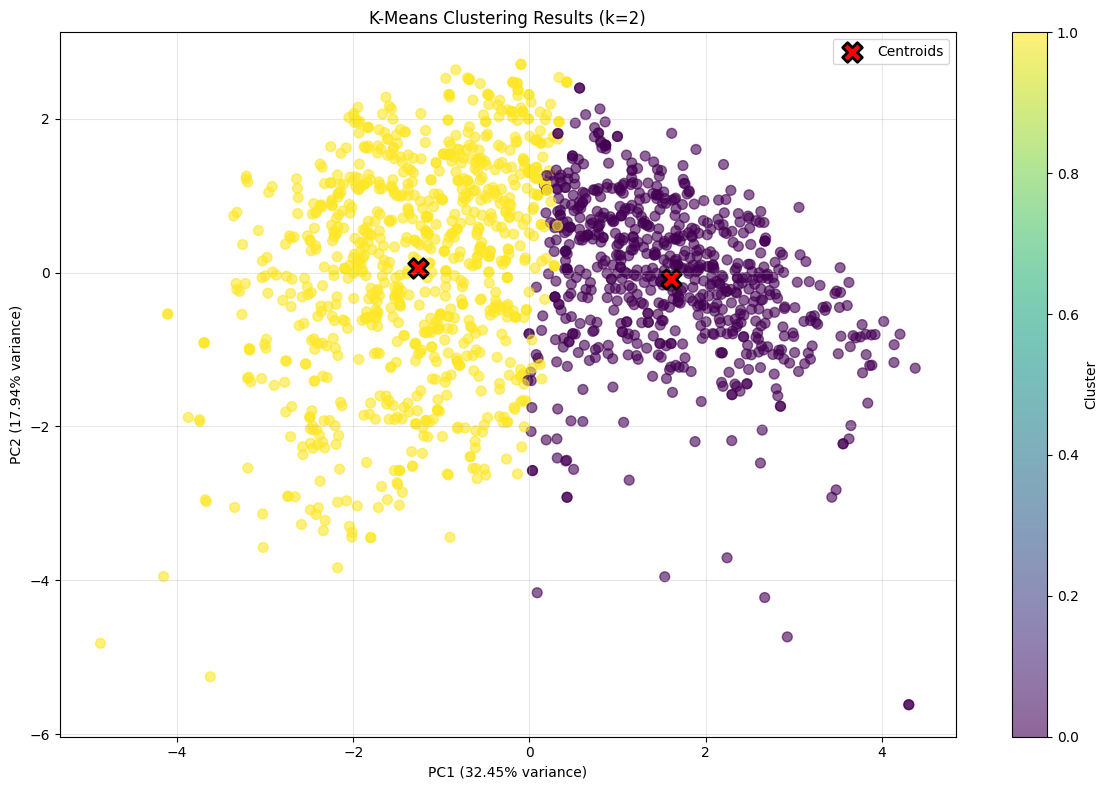

CLUSTER CHARACTERISTICS

Mean values of audio features by cluster:
         acousticness  danceability  energy  instrumentalness  liveness  \
cluster                                                                   
0               0.190         0.371   0.916             0.158     0.792   
1               0.298         0.546   0.695             0.169     0.256   

         loudness  speechiness    tempo  valence  popularity  duration_ms  
cluster                                                                    
0          -5.445        0.098  135.766    0.483      18.223   289775.502  
1          -8.173        0.047  118.462    0.660      22.807   232524.878  


Cluster Sizes:
cluster
0    709
1    901
Name: count, dtype: int64


CLUSTER PROFILES

Cluster 0 (n=709):
  - Average Popularity: 18.22
  - Energy: 0.916 (High Energy)
  - Danceability: 0.371
  - Acousticness: 0.190
  - Valence (Positivity): 0.483
  - Top 3 Albums: ['Voodoo Lounge Uncut (Live)', 'Live Licks', 'Tattoo You (Su

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings

warnings.filterwarnings('ignore')

# Cluster Analysis using PCA-reduced data

# Step 1: Determine the optimal number of clusters using elbow method and silhouette score
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, kmeans.labels_))

# Visualize elbow curve and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertias, marker='o', linestyle='-', linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(alpha=0.3)

# Silhouette score plot
axes[1].plot(K_range, silhouette_scores, marker='o', linestyle='-', linewidth=2, color='orange')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Different k Values')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Find optimal k based on silhouette score
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters (by Silhouette Score): {optimal_k}")
print(f"Silhouette scores for each k: {dict(zip(K_range, [f'{score:.4f}' for score in silhouette_scores]))}")
print("\n")

# Step 2: Apply K-means clustering with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)
dataset['cluster'] = clusters

# Evaluate clustering quality
silhouette_avg = silhouette_score(X_pca, clusters)
davies_bouldin = davies_bouldin_score(X_pca, clusters)

print(f"Clustering Results for k={optimal_k}:")
print(f"Silhouette Score: {silhouette_avg:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")
print(f"Cluster distribution: {np.bincount(clusters)}")
print("\n")

# Step 3: Visualize clusters in 2D PCA space
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6, s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', marker='X', s=200, edgecolors='black', linewidth=2, label='Centroids')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'K-Means Clustering Results (k={optimal_k})')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Step 4: Analyze cluster characteristics
print("="*80)
print("CLUSTER CHARACTERISTICS")
print("="*80)

cluster_analysis = dataset.groupby('cluster')[audio_features + ['popularity', 'duration_ms']].mean()
print("\nMean values of audio features by cluster:")
print(cluster_analysis.round(3))
print("\n")

# Cluster sizes
print("Cluster Sizes:")
print(dataset['cluster'].value_counts().sort_index())
print("\n")

# Step 5: Profile clusters
print("="*80)
print("CLUSTER PROFILES")
print("="*80)

for cluster_id in range(optimal_k):
    cluster_data = dataset[dataset['cluster'] == cluster_id]
    print(f"\nCluster {cluster_id} (n={len(cluster_data)}):")
    print(f"  - Average Popularity: {cluster_data['popularity'].mean():.2f}")
    print(f"  - Energy: {cluster_data['energy'].mean():.3f} (High Energy)" if cluster_data['energy'].mean() > 0.7 else f"  - Energy: {cluster_data['energy'].mean():.3f} (Low Energy)")
    print(f"  - Danceability: {cluster_data['danceability'].mean():.3f}")
    print(f"  - Acousticness: {cluster_data['acousticness'].mean():.3f}")
    print(f"  - Valence (Positivity): {cluster_data['valence'].mean():.3f}")
    print(f"  - Top 3 Albums: {cluster_data['album'].value_counts().head(3).index.tolist()}")